# Local EDA — MagangIn Jobs Indonesia
**Dataset:** `magangin_jobs_cleaned.csv`

**Tujuan:** Memahami realita kebutuhan skill magang tech di Indonesia

**Urutan analisis:**
1. Setup & Load
2. Data Quality Check
3. Skill Distribution
4. Role Distribution
5. Skill Complexity per Job
6. Skill Co-occurrence
7. Summary Insight

## 0. Setup & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
import sklearn
from jcopml.plot import plot_missing_value

In [2]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.family":       "sans-serif",
})

PALETTE   = "viridis"
COLOR_BAR = "#4C72B0"


# 1. Load Data

In [3]:
CSV_PATH = "../data/magangin_jobs_cleaned.csv"

df = pd.read_csv(CSV_PATH)
df = df.drop(columns=["location_raw"])

# Parse skills: string CSV → list Python
df["skills_list"] = (
    df["skills"]
    .fillna("")
    .apply(lambda s: [sk.strip() for sk in s.split(",") if sk.strip()])
)

print(f"Total records : {len(df)}")
print(f"Kolom         : {df.columns.tolist()}")
df.head(3)

Total records : 189
Kolom         : ['source', 'title', 'link', 'company_name', 'description_raw', 'skills', 'skills_count', 'role', 'location_city', 'region', 'jogja_tag', 'jabodetabek_tag', 'scraped_at', 'roadmap_url', 'is_tech', 'score', 'is_clean', 'skills_list']


,source,title,link,company_name,description_raw,skills,skills_count,role,location_city,region,jogja_tag,jabodetabek_tag,scraped_at,roadmap_url,is_tech,score,is_clean,skills_list
0,jobstreet,Software Developer,https://id.jobstreet.com/id/job/91908572,PT Swadharma Duta Data,Kami saat ini sedang mencari Software Develope...,"agile, android, angular, api, aws, ci/cd, cicd...",27,it-general,jakarta,Jabodetabek,False,True,2026-05-10 15:00:05,https://roadmap.sh/computer-science,True,87,True,"[agile, android, angular, api, aws, ci/cd, cic..."
1,jobstreet,Junior Software Engineer,https://id.jobstreet.com/id/job/91648206,PT Technet Vision Indonesia,Qualifications\n\nCore Requirements\n\nBachelo...,"agile, angular, api, aws, cicd, css, docker, g...",20,backend,jakarta,Jabodetabek,False,True,2026-05-10 14:59:42,https://roadmap.sh/backend,True,66,True,"[agile, angular, api, aws, cicd, css, docker, ..."
2,jobstreet,Full Stack AI Developer,https://id.jobstreet.com/id/job/91502813,PT Kharsima Alpha Teknologi,About the Role\n\nWe are looking for a Full St...,"api, aws, azure, cicd, css, database, django, ...",20,backend,jakarta,Jabodetabek,False,True,2026-05-10 15:11:03,https://roadmap.sh/backend,True,66,True,"[api, aws, azure, cicd, css, database, django,..."


In [4]:
df.shape

(189, 18)

## 2. Data Quality Check

**Goal:** Seberapa "noisy" data kita sebelum analisis?


2.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0")

print("=== Missing Values ===")
print(quality_df.to_string())

=== Missing Values ===
        Missing Count  Missing %
skills             23       12.2


2.2 Distribusi skills_count (termasuk 0)

In [6]:
zero_skill = (df["skills_count"] == 0).sum()
print(f"\nJob dengan 0 skill (tidak terdeteksi) : {zero_skill} ({zero_skill/len(df)*100:.1f}%)")
print(f"Job dengan skills kosong (NaN)        : {df['skills'].isna().sum()}")
print(f"\nskills_count stats:")
print(df["skills_count"].describe().round(2))


Job dengan 0 skill (tidak terdeteksi) : 23 (12.2%)
Job dengan skills kosong (NaN)        : 23

skills_count stats:
count    189.00
mean       5.39
std        4.76
min        0.00
25%        2.00
50%        5.00
75%        8.00
max       27.00
Name: skills_count, dtype: float64


2.3 Duplikat URL

In [7]:
dup_links = df["link"].duplicated().sum()
dup_title = df["title"].duplicated().sum()
print(f"Duplikat URL   : {dup_links}")
print(f"Duplikat title : {dup_title}")


Duplikat URL   : 0
Duplikat title : 26


2.4 Visualisasi: Missing Values

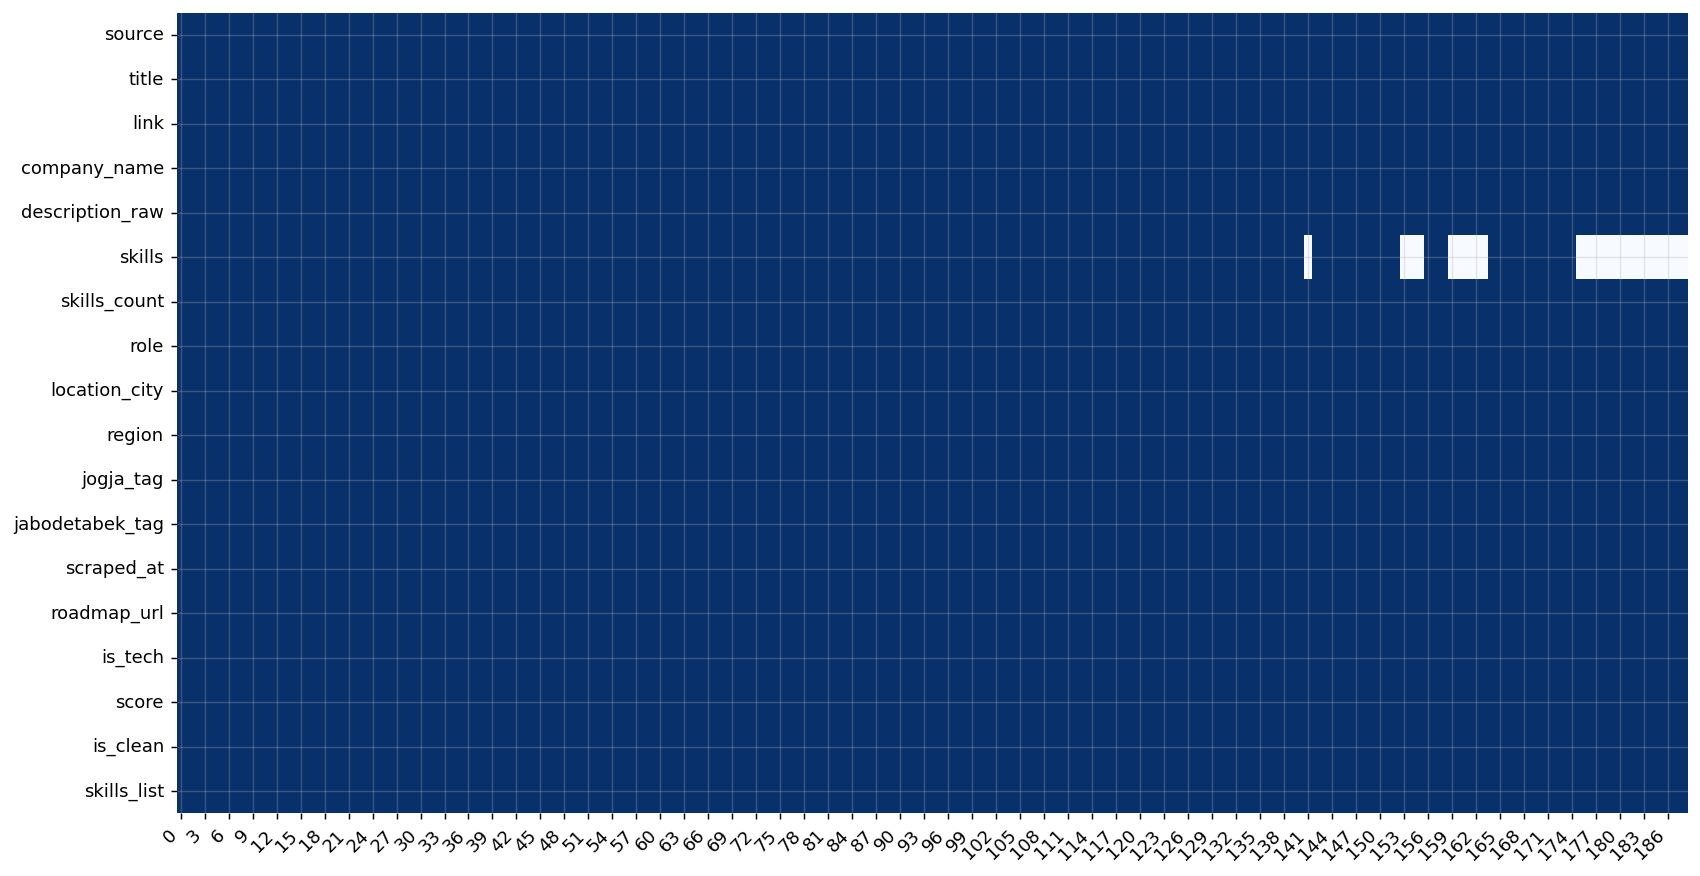

In [8]:
plot_missing_value(df)

In [9]:
df[df["skills"].isnull()] 


,source,title,link,company_name,description_raw,skills,skills_count,role,location_city,region,jogja_tag,jabodetabek_tag,scraped_at,roadmap_url,is_tech,score,is_clean,skills_list
141,glints,IT Support Intern,https://glints.com/id/opportunities/jobs/it-su...,Kalapa Technology,Deskripsi pekerjaan IT Support Intern Kalapa T...,NaN,0,it-general,yogyakarta,Yogyakarta,True,False,2026-05-10 14:51:17,https://roadmap.sh/computer-science,True,10,True,[]
153,glints,Reporting Social Media Analyst & Data Intern,https://glints.com/id/opportunities/jobs/repor...,Pt. Ivonesia Solusi Data (ivosights),Deskripsi pekerjaan Reporting Social Media Ana...,NaN,0,data,jakarta,Jabodetabek,False,True,2026-05-10 14:43:20,https://roadmap.sh/data-analyst,True,9,True,[]
154,jobstreet,Data Analyst Intern,https://id.jobstreet.com/id/job/91891985,"PT Matahari Putra Prima Tbk (Hypermart, Foodma...",Job Description:\n- Menggunakan tools seperti ...,NaN,0,data,tangerang,Jabodetabek,False,True,2026-05-10 15:01:53,https://roadmap.sh/data-analyst,True,9,True,[]
155,jobstreet,Data Analyst (Internship),https://id.jobstreet.com/id/job/91511788,Sumber Berkat Group,Kami membuka kesempatan bagi kandidat yang tel...,NaN,0,data,jakarta,Jabodetabek,False,True,2026-05-10 15:02:55,https://roadmap.sh/data-analyst,True,9,True,[]
159,glints,Graduate Intern - Software Engineer,https://glints.com/id/opportunities/jobs/gradu...,PT Formulatrix Indonesia,Deskripsi pekerjaan Graduate Intern - Software...,NaN,0,it-general,salatiga,Jawa Tengah,False,False,2026-05-10 14:41:59,https://roadmap.sh/computer-science,True,7,True,[]
160,glints,IT Intern,https://glints.com/id/opportunities/jobs/it-in...,Comika,Deskripsi pekerjaan IT Intern Comika\n\nJob De...,NaN,0,it-general,jakarta,Jabodetabek,False,True,2026-05-10 14:50:12,https://roadmap.sh/computer-science,True,7,True,[]
161,glints,IT Intern,https://glints.com/id/opportunities/jobs/it-in...,Comika,Deskripsi pekerjaan IT Intern Comika\n\nJob De...,NaN,0,it-general,jakarta,Jabodetabek,False,True,2026-05-10 14:50:22,https://roadmap.sh/computer-science,True,7,True,[]
162,glints,IT Intern (for Batam placement),https://glints.com/id/opportunities/jobs/it-in...,Glints Taploker,Deskripsi pekerjaan IT Intern (for Batam place...,NaN,0,it-general,jakarta,Jabodetabek,False,True,2026-05-10 14:50:46,https://roadmap.sh/computer-science,True,7,True,[]
163,jobstreet,Paid Internship Head Office X DISNAKER,https://id.jobstreet.com/id/job/91716143,PT. LUNA BOGA NARAYAN (Kopi Janji Jiwa),Jiwa Group saat ini membuka kesempatan Program...,NaN,0,it-general,jakarta,Jabodetabek,False,True,2026-05-10 14:54:40,https://roadmap.sh/computer-science,True,7,True,[]
175,jobstreet,IT Support Intern,https://id.jobstreet.com/id/job/91936938,PT. MEKAR ARMADA INVESTAMA,Kualifikasi\n\nMahasiswa aktif semester akhir ...,NaN,0,it-general,jakarta,Jabodetabek,False,True,2026-05-10 15:24:42,https://roadmap.sh/computer-science,True,7,True,[]


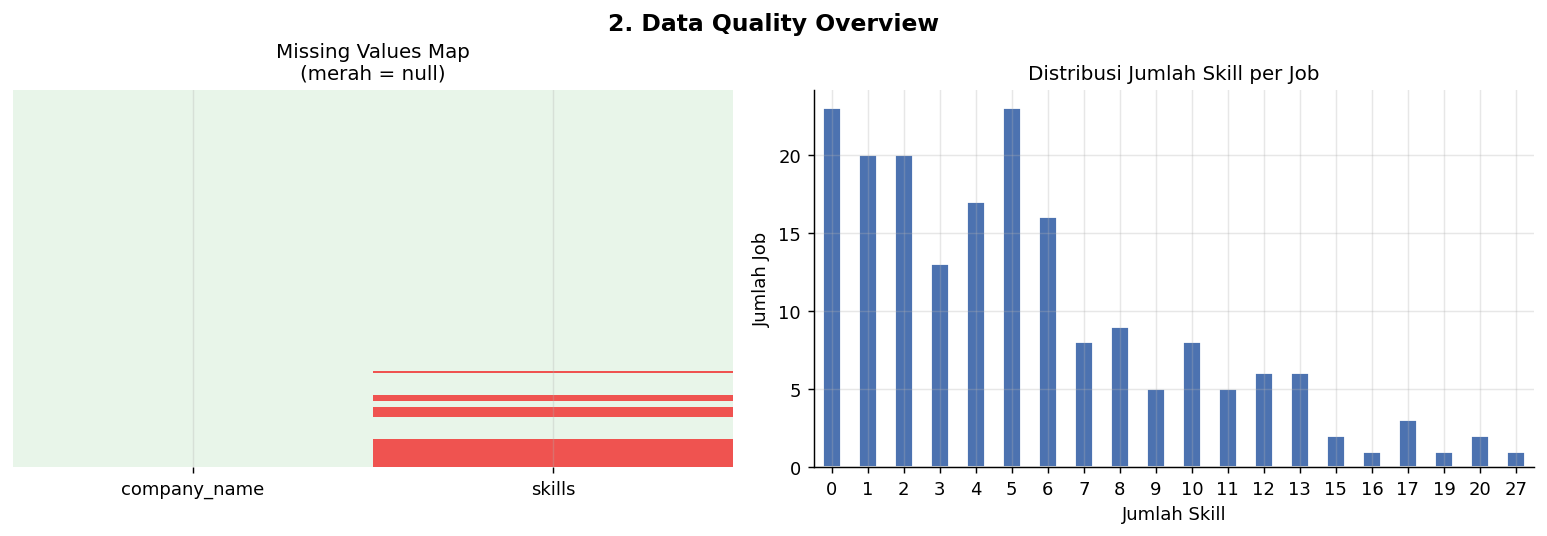

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap missing
sns.heatmap(
    df[["company_name", "skills"]].isnull(),
    cbar=False, yticklabels=False,
    cmap=["#e8f5e9", "#ef5350"],
    ax=axes[0]
)
axes[0].set_title("Missing Values Map\n(merah = null)", fontsize=11)

# Bar: skills_count distribution
df["skills_count"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=COLOR_BAR, edgecolor="white"
)
axes[1].set_title("Distribusi Jumlah Skill per Job", fontsize=11)
axes[1].set_xlabel("Jumlah Skill")
axes[1].set_ylabel("Jumlah Job")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.suptitle("2. Data Quality Overview", y=1.02, fontsize=13, fontweight="bold")
plt.show()


**Insight Data Quality:**
> Terdapat 14 baris yang tidak memiliki lokasi, kemungkinan terbesar adalah scrapper mencari lokasi di elemen yang salah. Ada 6 baris yang tidak memiliki nama perusahaan dan juga 3 baris yang tidak memiliki nilai skill.


## 3. Skill Distribution
**Pertanyaan:** Skill apa yang paling dibutuhkan? Apakah market lebih butuh hard skill atau soft skill?

3.1 Flatten semua skill

In [11]:
all_skills = [sk for skills in df["skills_list"] for sk in skills]
skill_counts = Counter(all_skills)
skill_df = pd.DataFrame(skill_counts.most_common(30), columns=["skill", "count"])

print(f"Total unique skills : {len(skill_counts)}")
print(f"\nTop 15 skills:")
print(skill_df.head(15).to_string(index=False))


Total unique skills : 74

Top 15 skills:
     skill  count
       sql     66
javascript     57
      java     52
       git     48
    python     47
  security     47
  database     43
       api     37
     react     37
      html     36
       css     35
      cicd     28
     agile     24
      node     21
       php     21


3.2 Top 20 Skill Bar Chart

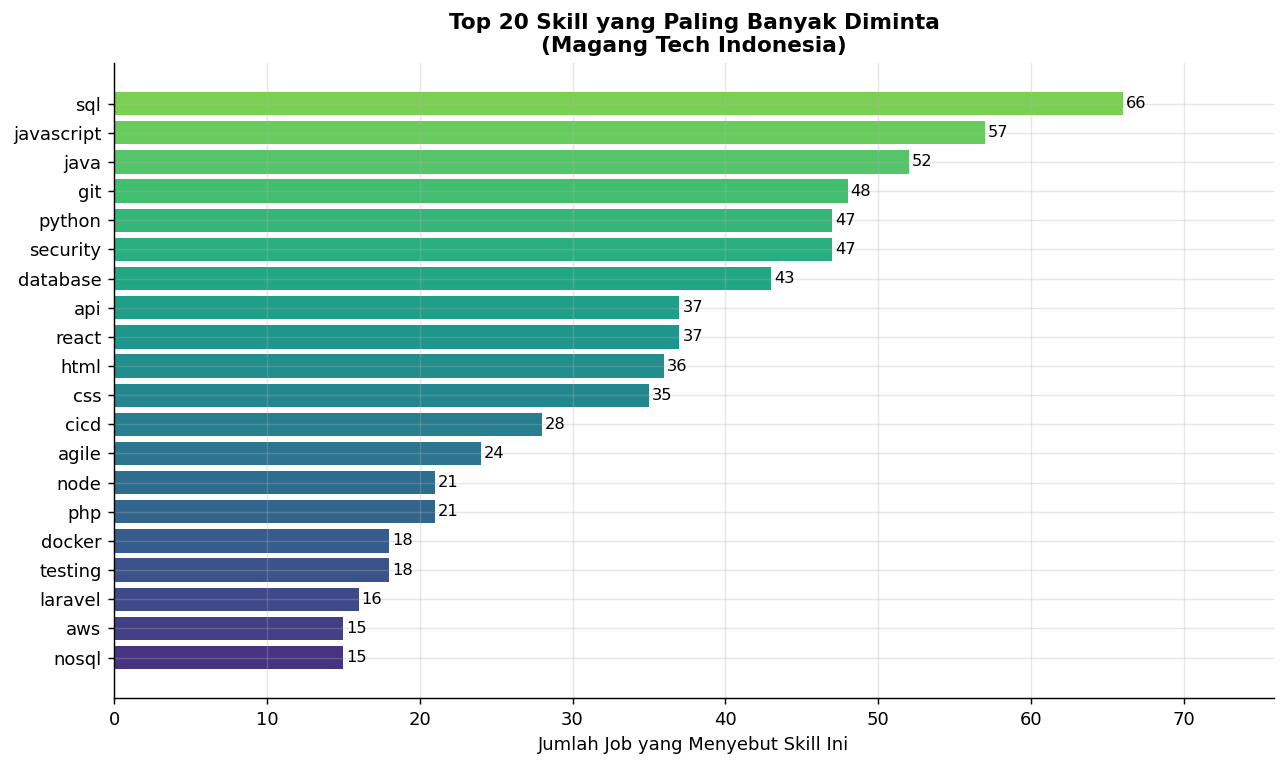

In [12]:
top20 = skill_df.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis_r(np.linspace(0.2, 0.85, len(top20)))
bars = ax.barh(top20["skill"][::-1], top20["count"][::-1], color=colors[::-1])

for bar, val in zip(bars, top20["count"][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", ha="left", fontsize=9)

ax.set_title("Top 20 Skill yang Paling Banyak Diminta\n(Magang Tech Indonesia)", fontsize=12, fontweight="bold")
ax.set_xlabel("Jumlah Job yang Menyebut Skill Ini")
ax.set_xlim(0, top20["count"].max() * 1.15)
plt.tight_layout()
plt.show()


3.3 Kategorisasi skill: Hard vs Tools vs Platform

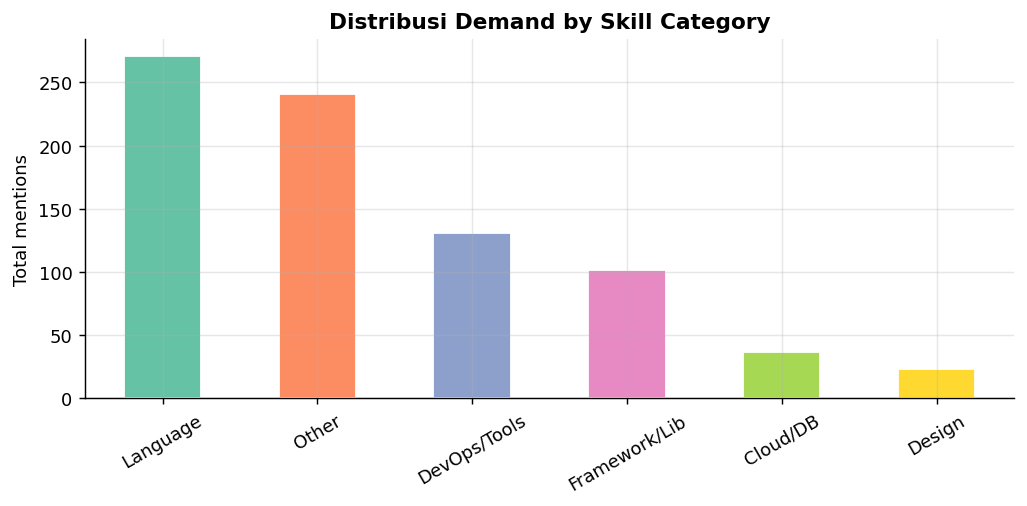


Breakdown per kategori:
category
Language         271
Other            241
DevOps/Tools     131
Framework/Lib    102
Cloud/DB          37
Design            23


In [13]:
HARD_SKILLS  = {"python","javascript","typescript","java","sql","php","kotlin","swift","go","r","cpp","c"}
FRAMEWORK    = {"react","vue","angular","nextjs","django","flask","fastapi","laravel","springboot",
                "node","express","flutter","tensorflow","pytorch","sklearn","spark","pandas","numpy"}
TOOLS_DEVOPS = {"git","docker","kubernetes","linux","cicd","postman","agile"}
CLOUD        = {"aws","gcp","azure","firebase","elasticsearch","mongodb","redis"}
DESIGN       = {"figma","adobexd","canva"}
PRODUCTIVITY = {"excel","jupyter","tableau","powerbi"}

def categorize(skill):
    if skill in HARD_SKILLS:  return "Language"
    if skill in FRAMEWORK:    return "Framework/Lib"
    if skill in TOOLS_DEVOPS: return "DevOps/Tools"
    if skill in CLOUD:        return "Cloud/DB"
    if skill in DESIGN:       return "Design"
    if skill in PRODUCTIVITY: return "Productivity"
    return "Other"

skill_df["category"] = skill_df["skill"].apply(categorize)
cat_counts = skill_df.groupby("category")["count"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", len(cat_counts)), edgecolor="white")
ax.set_title("Distribusi Demand by Skill Category", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total mentions")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("\nBreakdown per kategori:")
print(cat_counts.to_string())


**Insight Skill Distribution:**

> **1. SQL & Java mendominasi pasar magang tech Indonesia.**
> Ini menunjukkan bahwa kemampuan mengelola data (query, manipulasi database) dan penguasaan bahasa masih menjadi fondasi utama yang dicari perusahaan.

> **2. Excel berada di posisi ke-3 (38.8%).**
> Ini mengindikasikan bahwa banyak role magang masih mengharapkan kemampuan spreadsheet/reporting di samping coding.

> **3. Pasar menuntut skill *praktis*, bukan hanya teori.**
> Kategori **Language** mendominasi (100 mention), diikuti **Tools/DevOps** (50) dan **Framework** (42). Artinya perusahaan tidak hanya mau intern yang bisa coding, tapi juga harus familiar dengan Git (28.6%), CI/CD (20.4%), Agile workflow (30.6%), dan framework production-ready seperti React & Node.

> **4. Cloud & DevOps mulai jadi ekspektasi dasar.**
> AWS (12.2%), Docker (10.2%), Kubernetes (8.2%), dan GCP (8.2%) sudah muncul di lowongan magang — bukan hanya posisi senior. Ini sinyal bahwa exposure ke cloud infrastructure semakin dianggap baseline skill.

> **5. Korelasi kuat dengan distribusi role.**
> Dominasi SQL, Java, dan Excel sejalan dengan fakta bahwa role **IT General (20)** dan **Data (14)** mendominasi dataset. Kedua role ini memang heavily rely on database querying dan data processing.


## 4. Role Distribution
**Pertanyaan:** Role apa paling banyak? Apakah market condong ke satu bidang?


In [14]:
role_counts = df["role"].value_counts()
print("Distribusi Role:")
print(role_counts.to_string())

Distribusi Role:
role
backend       40
it-general    35
cyber         20
frontend      19
qa            19
data          14
ai/ml         13
ui/ux         10
fullstack      9
devops         8
mobile         2


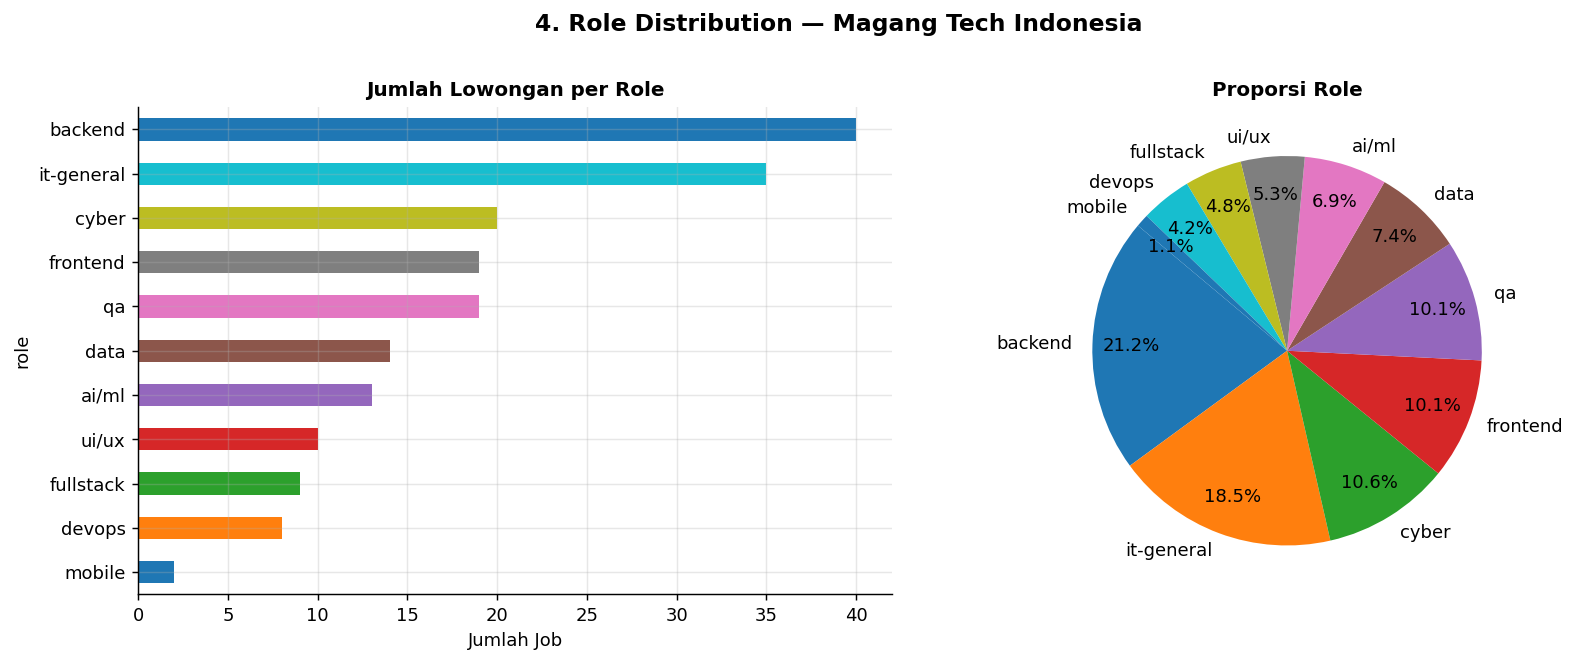

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = sns.color_palette("tab10", len(role_counts))
role_counts.plot(kind="barh", ax=axes[0], color=colors[::-1])
axes[0].set_title("Jumlah Lowongan per Role", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Jumlah Job")
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(
    role_counts.values,
    labels=role_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("tab10", len(role_counts)),
    pctdistance=0.8
)
axes[1].set_title("Proporsi Role", fontsize=11, fontweight="bold")

plt.suptitle("4. Role Distribution — Magang Tech Indonesia", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


4.2 Region vs Role heatmap

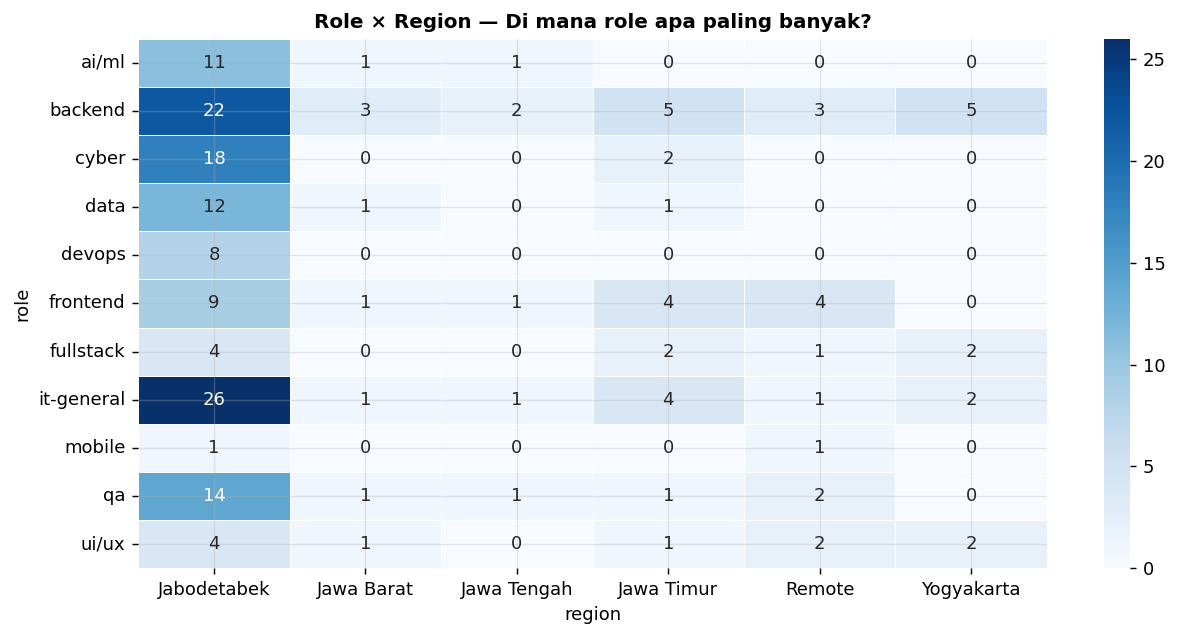

In [16]:
role_region = pd.crosstab(df["role"], df["region"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    role_region,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Role × Region — Di mana role apa paling banyak?", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


**Insight Role Distribution:**
> **1. IT-general & Data mendominasi** — pasar Indonesia belum terlalu spesifik.

> **2. Banyak perusahaan mencari 'generalis' yang bisa banyak hal.**

> **3. Peluang terbesar ada di posisi yang sifatnya broad/umum dan data-related.**


## 5. Skill Complexity per Job
**Pertanyaan:** Rata-rata butuh berapa skill? Apakah magang Indo entry-level friendly?


Filter job yang punya minimal 1 skill

In [17]:
df_with_skills = df[df["skills_count"] > 0]

mean_skills = df_with_skills["skills_count"].mean()
median_skills = df_with_skills["skills_count"].median()

print(f"Rata-rata skill per job : {mean_skills:.1f}")
print(f"Median skill per job    : {median_skills:.1f}")
print(f"Min                     : {df_with_skills['skills_count'].min()}")
print(f"Max                     : {df_with_skills['skills_count'].max()}")
print()

# Labelkan complexity
def complexity_label(n):
    if n <= 3:  return "Simple (≤3)"
    if n <= 6:  return "Moderate (4–6)"
    return "Complex (7+)"

df["complexity"] = df["skills_count"].apply(complexity_label)
print(df["complexity"].value_counts())

Rata-rata skill per job : 6.1
Median skill per job    : 5.0
Min                     : 1
Max                     : 27

complexity
Simple (≤3)       76
Complex (7+)      57
Moderate (4–6)    56
Name: count, dtype: int64


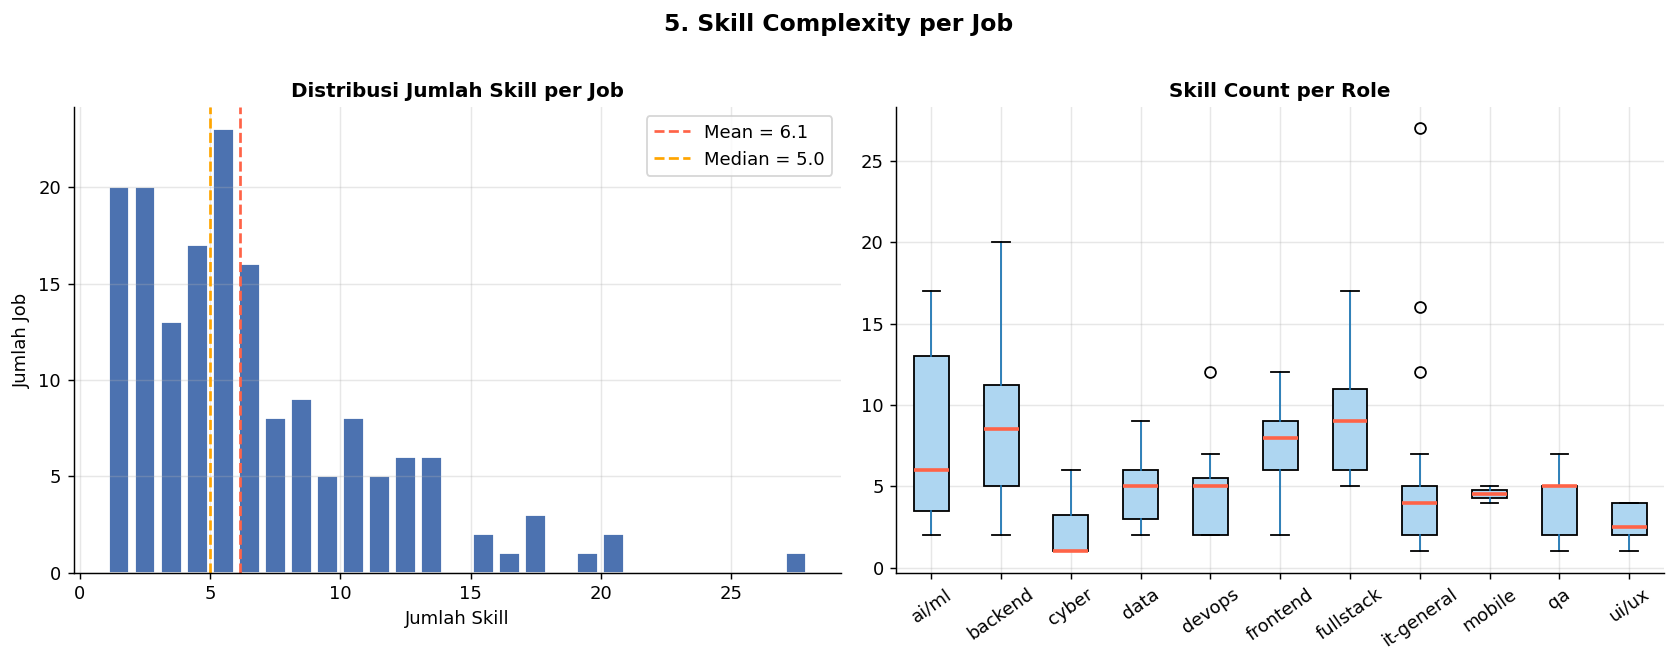

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram distribusi
df_with_skills["skills_count"].hist(
    bins=range(1, df_with_skills["skills_count"].max() + 2),
    ax=axes[0], color=COLOR_BAR, edgecolor="white", rwidth=0.8
)
axes[0].axvline(mean_skills, color="tomato", linestyle="--", label=f"Mean = {mean_skills:.1f}")
axes[0].axvline(median_skills, color="orange", linestyle="--", label=f"Median = {median_skills:.1f}")
axes[0].set_title("Distribusi Jumlah Skill per Job", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Jumlah Skill")
axes[0].set_ylabel("Jumlah Job")
axes[0].legend()

# Boxplot per role
df_with_skills.boxplot(
    column="skills_count", by="role",
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor="#AED6F1"),
    medianprops=dict(color="tomato", linewidth=2)
)
axes[1].set_title("Skill Count per Role", fontsize=11, fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
plt.suptitle("")  # hapus judul auto dari boxplot

plt.suptitle("5. Skill Complexity per Job", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# Complexity breakdown: Simple / Moderate / Complex

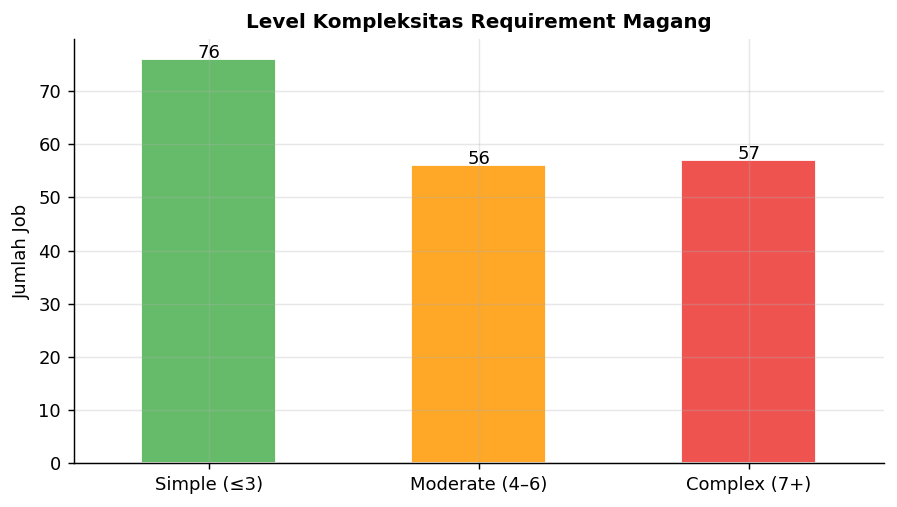

In [19]:
complexity_order = ["Simple (≤3)", "Moderate (4–6)", "Complex (7+)"]
comp_counts = df["complexity"].value_counts().reindex(complexity_order)

fig, ax = plt.subplots(figsize=(7, 4))
comp_counts.plot(
    kind="bar", ax=ax,
    color=["#66BB6A", "#FFA726", "#EF5350"],
    edgecolor="white"
)
ax.set_title("Level Kompleksitas Requirement Magang", fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Jumlah Job")
ax.tick_params(axis="x", rotation=0)

for i, v in enumerate(comp_counts):
    ax.text(i, v + 0.2, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Insight Skill Complexity:**
> Rata-rata lowongan meminta 5.4 skill dengan median di 4 skill. Sekitar 47% lowongan minta 5+ skill, menunjukkan bahwa meski ini posisi magang, ekspektasi multi-skill sudah cukup tinggi. Mahasiswa yang menguasai minimal 4–5 skill (misal: SQL, Java, Python, Git) sudah bisa cover mayoritas lowongan.




## 6. Skill Co-occurrence

**Pertanyaan:** Skill apa yang selalu muncul barengan?

**Insight:** Dasar untuk bikin learning roadmap.


6.1 Hitung pasangan skill yang co-occur

In [20]:
co_occur = Counter()
for skills in df["skills_list"]:
    for pair in combinations(sorted(set(skills)), 2):
        co_occur[pair] += 1

co_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in co_occur.most_common(40)],
    columns=["skill_a", "skill_b", "count"]
)

print("Top 15 pasangan skill yang sering muncul barengan:")
print(co_df.head(15).to_string(index=False))


Top 15 pasangan skill yang sering muncul barengan:
   skill_a    skill_b  count
      java javascript     44
  database        sql     41
javascript        sql     33
      html javascript     32
javascript      react     31
       git        sql     30
      html       java     30
       api        git     29
    python        sql     29
       css       html     29
       css javascript     29
       git javascript     28
      java        sql     28
  database javascript     26
       css       java     26


6.2 Co-occurrence heatmap (top N skills)

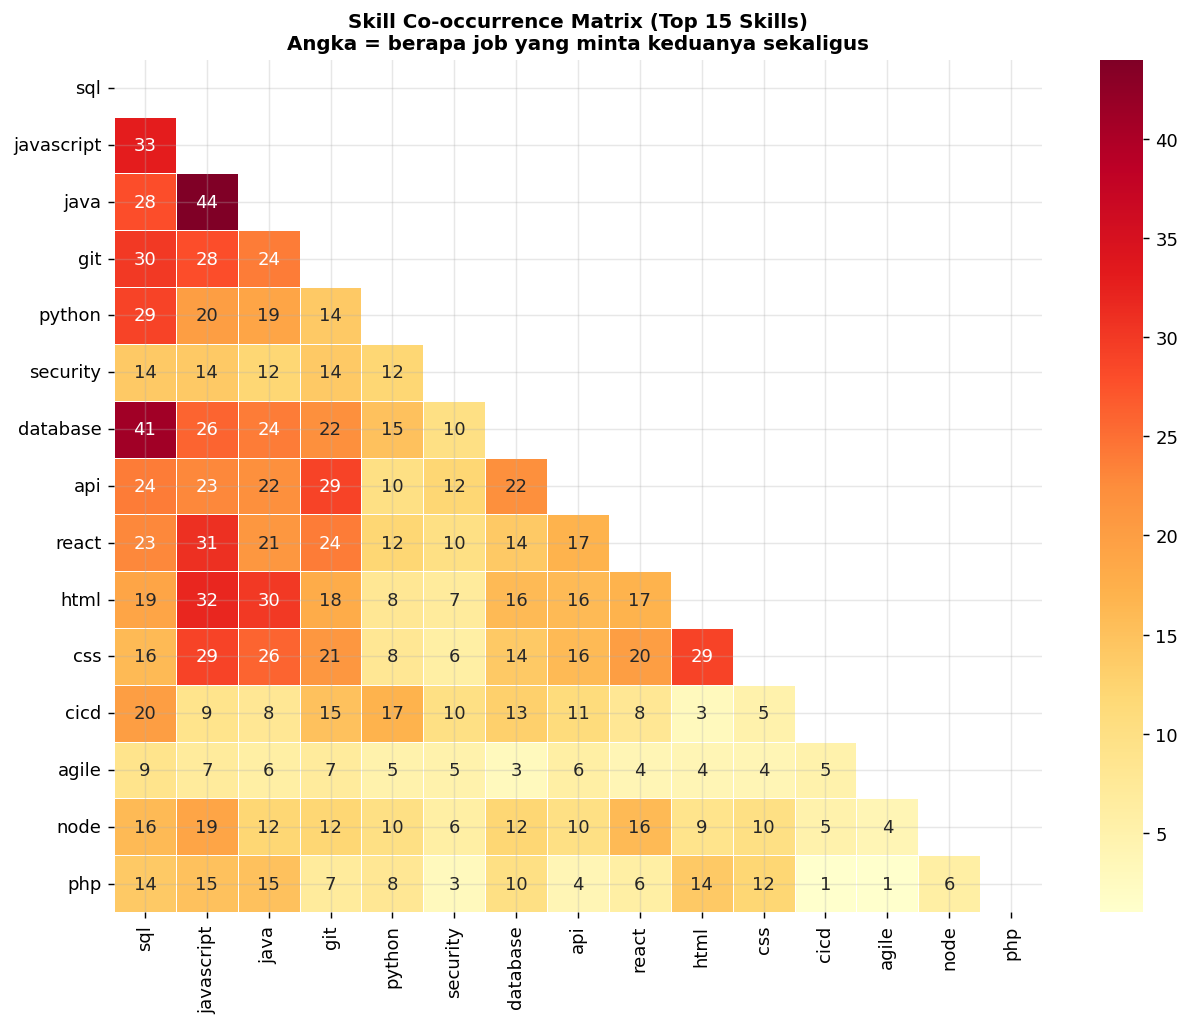

In [21]:
TOP_N = 15
top_skills = [s for s, _ in skill_counts.most_common(TOP_N)]

# Buat matrix
matrix = pd.DataFrame(0, index=top_skills, columns=top_skills)
for skills in df["skills_list"]:
    filtered = [s for s in skills if s in top_skills]
    for a, b in combinations(sorted(set(filtered)), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(matrix, dtype=bool))  # sembunyikan segitiga atas (redundant)
sns.heatmap(
    matrix, mask=mask,
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.3,
    ax=ax
)
ax.set_title(f"Skill Co-occurrence Matrix (Top {TOP_N} Skills)\nAngka = berapa job yang minta keduanya sekaligus",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


6.3 Top pasangan — bar chart

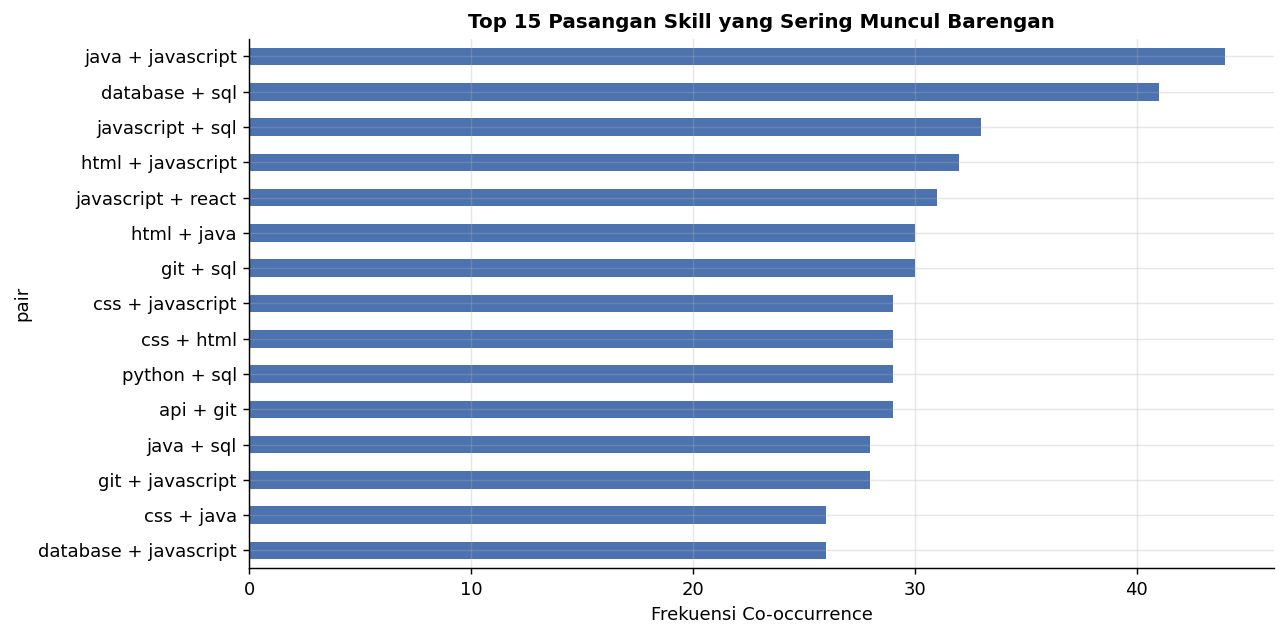

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
top_pairs = co_df.head(15).copy()
top_pairs["pair"] = top_pairs["skill_a"] + " + " + top_pairs["skill_b"]

top_pairs.sort_values("count").plot(
    kind="barh", x="pair", y="count",
    ax=ax, color=COLOR_BAR, legend=False
)
ax.set_title("Top 15 Pasangan Skill yang Sering Muncul Barengan", fontsize=11, fontweight="bold")
ax.set_xlabel("Frekuensi Co-occurrence")
plt.tight_layout()
plt.show()


**Insight Co-occurrence:**
> Pasangan skill yang paling sering muncul bersamaan adalah Java + SQL (16x), diikuti Python + SQL (13x) dan Java + JavaScript (12x). SQL menjadi "penghubung" dan hampir selalu dipasangkan dengan bahasa apapun. Pola ini menguatkan bahwa market magang Indonesia sangat data-oriented: apapun bahasa utamanya, kemampuan query database hampir selalu jadi syarat pendamping.



## 7. Summary: Menjawab 4 Pertanyaan Utama

In [23]:
print("=" * 60)
print("RINGKASAN EDA — MAGANG TECH INDONESIA")
print("=" * 60)

# Q1: Skill paling penting
top5_skills = [s for s, _ in skill_counts.most_common(5)]
print(f"\n1. Top 5 skill paling dibutuhkan:")
for i, (sk, cnt) in enumerate(skill_counts.most_common(5), 1):
    print(f"   {i}. {sk:15} — {cnt} job")

# Q2: Role paling banyak
top_role = role_counts.idxmax()
print(f"\n2. Role paling banyak: '{top_role}' ({role_counts[top_role]} lowongan)")

# Q3: Seberapa demanding
pct_moderate_plus = (df["skills_count"] >= 4).mean() * 100
print(f"\n3. {pct_moderate_plus:.0f}% job butuh 4+ skill → market cukup demanding")
print(f"   Rata-rata {mean_skills:.1f} skill per job")

# Q4: Generalist vs Specialist
top2_role_pct = role_counts.head(2).sum() / len(df) * 100
print(f"\n4. Top 2 role ({role_counts.index[0]}, {role_counts.index[1]})")
print(f"   = {top2_role_pct:.0f}% dari total → market cenderung GENERALIST")

print("\n" + "=" * 60)


RINGKASAN EDA — MAGANG TECH INDONESIA

1. Top 5 skill paling dibutuhkan:
   1. sql             — 66 job
   2. javascript      — 57 job
   3. java            — 52 job
   4. git             — 48 job
   5. python          — 47 job

2. Role paling banyak: 'backend' (40 lowongan)

3. 60% job butuh 4+ skill → market cukup demanding
   Rata-rata 6.1 skill per job

4. Top 2 role (backend, it-general)
   = 40% dari total → market cenderung GENERALIST



## Final Narrative

 
> Dataset ini mencakup 48 lowongan magang tech yang di-scrape dari tiga platform (JobStreet 35, Glints 12, Kalibrr 2). Mayoritas posisi terkonsentrasi di Jabodetabek (73.5%) — Jakarta masih jadi pusat gravity magang tech Indonesia.

> Dari sisi skill, SQL (51%) dan Java (49%) mendominasi, diikuti Excel, Python, dan JavaScript. Pasar tidak hanya minta bahasa pemrograman — tools seperti Git, CI/CD, dan Agile juga sering disebut. Artinya ekspektasi bersifat praktis dan production-ready, bukan sekadar teori.

> Landscape role didominasi IT General (41%) dan Data (29%). Dua kategori ini saja sudah ~70% dari total. Role spesialis seperti AI/ML, DevOps, dan Mobile masih sangat langka — market magang Indonesia masih condong ke generalist.

> Median skill yang diminta hanya 4 skill per lowongan — angka yang realistis untuk mahasiswa. Meski ada outlier yang minta 18 skill, mayoritas lowongan cukup accessible. Market magang tech Indonesia bisa dibilang cukup ramah untuk entry-level asal punya fondasi dasar.

> So what? Mahasiswa yang ingin kompetitif cukup fokus kuasai SQL + satu bahasa utama (Java/Python) + Git + 1 framework. Empat skill ini sudah meng-cover mayoritas lowongan. Tambahkan exposure ke Docker/AWS sebagai diferensiasi, dan kamu sudah di atas rata-rata kandidat magang.


